# HASP · Reading a neighbourhood from data
### Leeds Digital Festival - hands-on workshop

You've seen what HASP is. Now lets look at some neighbourhood-level data.

Everything here is **real, open data at LSOA level** (a Lower-layer Super Output Area is a
neighbourhood of ~1,500 people). In this session we focus on **Leeds** by default - flip one switch (`LEEDS_ONLY = False`) to run
all of **West Yorkshire** (Leeds, Bradford, Kirklees, Calderdale, Wakefield) instead.

| Dataset | What it tells us | Direction (as used here) |
|---|---|---|
| **PPFI** (HASP) | priority for food insecurity | decile **1 = highest priority** (worst) |
| **IMD 2025** | overall deprivation | decile **1 = most deprived** |
| **Which? Insulation Index** | homes most in need of insulation (poor fabric + fuel-poverty risk) | decile **1 = greatest need** † |

**All three indices are lined up the same way: decile 1 = worst.** 

> † The insulation index is *published* the other way round (its decile 1 = **lowest** need).
> `load_area()` flips it on load so it matches the other two. Different data providers pick different
> directions, do check.

4 questions:

| | Question | Section |
|---|---|---|
| **A** | What are we even looking at? | Meet the area |
| **B** | Where is food priority worst? | First map |
| **C** | Do different problems hit the same places? | Agreement |
| **D** | Where do the burdens stack up? | The takeaway |

> **Start:** `Runtime → Run all`, then read from the top. First run installs packages (~1 min).

## Setup - run this first

One config block holds everything you'd change:
- `LEEDS_ONLY` - ships as `True` (Leeds only); set it to `False` for all of West Yorkshire.
- `DATA` - change it if you uploaded the files somewhere other than a `data/` folder.

In [1]:
# ---------------- CONFIG ----------------
DATA       = "data"      # folder holding the CSVs + GeoJSON ("" if you uploaded to the root)
LEEDS_ONLY = True       # <-- set True to run just Leeds instead of all of West Yorkshire
WORST      = 2           # "high need" = worst fifth of an index (decile 1-2)


In [ ]:
# Colab: h3 isn't preinstalled (geopandas/seaborn are). Safe to re-run.
%pip install -q h3

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import h3
import seaborn as sns
from matplotlib.colors import ListedColormap
from IPython.display import display

BOUNDARIES = "Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BGC_V5.gpkg"
PPFI       = "hasp_ppfi_v2.1.csv"
IMD        = "imd_2025.csv"
INSULATION = "which_insulation_index.csv"
# ----------------------------------------


# dark: worse, light: better (for deciles, 1 = worst = darkest)
PALETTE = ["#08306b", "#08519c", "#2171b5", "#4292c6", "#6baed6",
                             "#9ecae1", "#c6dbef", "#deebf7", "#f7fbff", "#ffffff"]
HASP_BLUES   = ListedColormap(PALETTE[::-1])            # light -> dark  (higher value = darker)
HASP_BLUES_R = ListedColormap(PALETTE)                 # dark -> light  (deciles: 1 = worst = darkest)
DISTRICTS = ["Leeds"] if LEEDS_ONLY else ["Leeds", "Bradford", "Kirklees", "Calderdale", "Wakefield"]
AREA_NAME = "Leeds" if LEEDS_ONLY else "West Yorkshire"

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "figure.facecolor": "white",
                    "axes.spines.top": False, "axes.spines.right": False})
RNG = np.random.default_rng(0)
print(f"ready · area = {AREA_NAME}")

ready · area = Leeds


### The handful of functions we'll reuse

filtering to your area, converting map projections, cleaning odd file headers,
joining the three index files, and lining up the insulation index with the others - all live inside
`load_area()`. 
**You don't need to read these to do the workshop** - skim the names:

- `load_area()` - every LSOA in your chosen area, with all three indices joined (and insulation flipped)
- `high_need(decile)` - True for the worst fifth (decile 1–2)
- `show_map(...)` - a static, HASP-styled choropleth (blue ramp, thin borders)

In [15]:
def load_area():
    """Return one tidy GeoDataFrame: every LSOA in the chosen area (DISTRICTS) with the three headline
    indices (plus PPFI's 7 domains) joined. Parts - area filter, projection, clean headers, joins,
    and flipping the insulation index so it points the same way as the others."""

    # 1. LSOA polygons for England & Wales; keep the chosen districts (district is in the LSOA name)
    geo = gpd.read_file(f"{DATA}/{BOUNDARIES}")
    geo["district"] = geo["LSOA21NM"].str.rsplit(" ", n=1).str[0]
    area = (geo[geo["district"].isin(DISTRICTS)]
            .loc[:, ["LSOA21CD", "LSOA21NM", "district", "geometry"]]
            .rename(columns={"LSOA21CD": "lsoa", "LSOA21NM": "name"})
            .to_crs(4326)                       # UK grid is EPSG:27700, but we want EPSG:4326 for web mapping
            .reset_index(drop=True))

    def join_index(csv, code_col, value_col, new_name):
        """Read one index file and return a clean two-column table to merge on the LSOA code."""
        t = pd.read_csv(f"{DATA}/{csv}")
        t.columns = [c.strip().lstrip("﻿") for c in t.columns]   # clean up any stray characters in the headers
        return (t[[code_col, value_col]]
                .rename(columns={code_col: "lsoa", value_col: new_name})
                .drop_duplicates("lsoa"))

    # PPFI: England only. Combined priority decile + the 7 domain deciles behind it.
    PPFI_DOMAINS = {
        "pp_dec_domain_supermarket_proximity":     "d_supermarket_proximity",
        "pp_dec_domain_supermarket_accessibility": "d_supermarket_access",
        "pp_dec_domain_ecommerce_access":          "d_online_access",
        "pp_dec_domain_nonsupermarket_proximity":  "d_nonsupermarket",
        "pp_dec_domain_socio_demographic":         "d_socioeconomic",
        "pp_dec_domain_food_for_families":         "d_family_support",
        "pp_dec_domain_fuel_poverty":              "d_fuel_poverty",
    }
    ppfi = pd.read_csv(f"{DATA}/{PPFI}")
    ppfi = (ppfi[ppfi["country"] == "E"][["lsoa21cd", "pp_dec_combined", *PPFI_DOMAINS]]
              .rename(columns={"lsoa21cd": "lsoa", "pp_dec_combined": "food_decile", **PPFI_DOMAINS}))

    merged = (area.merge(ppfi, on="lsoa", how="left")
                .merge(join_index(IMD, "lsoa_code", "imd_decile", "imd_decile"), on="lsoa", how="left")
                .merge(join_index(INSULATION, "Geo_code", "Combined_deciles", "insulation_decile"), on="lsoa", how="left"))

    # The insulation index is published the other way round (its decile 1 = LOWEST need).
    # Flip it so decile 1 = worst everywhere, matching PPFI and IMD.
    merged["insulation_decile"] = 11 - merged["insulation_decile"]
    return merged


def high_need(decile_series):
    """True where a neighbourhood is in the worst fifth (decile 1-WORST) of an index."""
    return decile_series <= WORST


def show_map(gdf, column, title, cmap=HASP_BLUES_R):
    """Static HASP-styled choropleth: blue ramp, thin borders, clean layout.
    Default cmap suits deciles (1 = worst is darkest); pass HASP_BLUES for 'more = darker' fields."""
    fig, ax = plt.subplots(figsize=(8,8))
    gdf.plot(column=column, cmap=cmap, ax=ax, legend=True,
            edgecolor="#222222", linewidth=0.15,
            missing_kwds={"color": "#f0f0f0", "edgecolor": "#222222",
                        "linewidth": 0.15, "label": "no data"},
            legend_kwds={"shrink": 0.55})
    ax.set_title(title, fontsize=12, weight="bold", loc="left", pad=10)
    ax.set_axis_off()
    fig.tight_layout()
    plt.show()

def convert_lsoa_to_h3shape(gdf_lsoa_inp, res=10):
    gdf_lsoa = gdf_lsoa_inp.copy()
    intial_crs = gdf_lsoa.crs
    if intial_crs != "EPSG:4326":
        gdf_lsoa = gdf_lsoa.to_crs("EPSG:4326")
        print(f"Converted CRS from {intial_crs} to EPSG:4326 for H3 processing.")

    h3shapes = {}
    h3cells = {}
    empty_shapes = 0
    for i, row in gdf_lsoa.iterrows():
        geom = row.geometry
        try:
            # Using h3.geo_to_h3shape requires h3-py >= 4.0
            h3shape = h3.geo_to_h3shape(geom)
            cells = h3.h3shape_to_cells(h3shape, res=res)
            refined_h3shape = h3.cells_to_h3shape(cells)

            if len(cells) == 0:
                empty_shapes += 1
                # If shape is empty, we keep the key but value might be empty/invalid geometry
                # Depending on library version this might need handling. 
                # For plotting, an empty geometry usually just doesn't show.
            
            h3shapes[row['lsoa']] = refined_h3shape
            h3cells[row['lsoa']] = cells
        except Exception as e:
            print(f"Error converting LSOA {row['lsoa']}: {e}")
            empty_shapes += 1

    h3shape_gdf = gpd.GeoDataFrame({'lsoa': list(h3shapes.keys()),
                                    'h3_cells': list(h3cells.values()),
                                    'geometry': list(h3shapes.values())})
    
    # Drop original geometry and merge new H3 geometry
    gdf_lsoa_dropped = gdf_lsoa.drop(columns=['geometry'])
    merged_df = gdf_lsoa_dropped.merge(h3shape_gdf, on='lsoa')
    
    # Re-create GeoDataFrame with new geometry
    merged_gdf = gpd.GeoDataFrame(merged_df, geometry='geometry', crs="EPSG:4326")
    
    # Project back to original CRS
    if intial_crs is not None:
        merged_gdf = merged_gdf.to_crs(intial_crs)

    if empty_shapes > 0:
        print(f"Warning: {empty_shapes} empty H3 shapes found out of {len(gdf_lsoa)} LSOAs at resolution {res}.")
    else:
        print(f"Success: no empty H3 shapes. Converted {len(gdf_lsoa)} LSOAs to H3 shapes at resolution {res}.")
    return merged_gdf

def show_map_h3(gdf, column, title, cmap=HASP_BLUES_R, res=10):
    """Static HASP-styled choropleth for H3 shapes: blue ramp, thin borders, clean layout.
    Default cmap suits deciles (1 = worst is darkest); pass HASP_BLUES for 'more = darker' fields."""
    fig, ax = plt.subplots(figsize=(8,8))
    gdf_h3 = convert_lsoa_to_h3shape(gdf, res=res)
    gdf_h3.plot(column=column, cmap=cmap, ax=ax, legend=True,
            edgecolor="#222222", linewidth=0.15,
            missing_kwds={"color": "#f0f0f0", "edgecolor": "#222222",
                        "linewidth": 0.15, "label": "no data"},
            legend_kwds={"shrink": 0.55})
    ax.set_title(title, fontsize=12, weight="bold", loc="left", pad=10)
    ax.set_axis_off()
    fig.tight_layout()
    plt.show()

print("functions ready: load_area · high_need · show_map · convert_lsoa_to_h3shape · show_map_h3")

functions ready: load_area · high_need · show_map · convert_lsoa_to_h3shape · show_map_h3


---
# A. What are we even looking at?

**What the next cell does:** loads every LSOA in your chosen area, joins the three index datasets onto it,
and prints a per-district summary.

**Why:** before any analysis, get to know the data - how many LSOAs, where they are, and how
complete each column is.

**How to read it:** each row is a Local Authority District (LAD). `share_high_food_need` is the fraction of its
neighbourhoods in the worst fifth for food priority, so higher = more of the LAD is struggling.
Notice `insulation_decile` isn't quite 100%, a few neighbourhoods are missing.

In [16]:
area = load_area()
print(f"{AREA_NAME}: {len(area):,} LSOAs across {area['district'].nunique()} district(s)\n")

coverage = {c: f"{area[c].notna().mean():.0%}" for c in
          ["food_decile", "imd_decile", "insulation_decile"]}
print("data coverage:", coverage, "\n")

summary = (area.groupby("district")
               .agg(lsoas=("lsoa", "size"),
                    share_high_food_need=("food_decile", lambda s: high_need(s).mean()))
               .round(2)
               .sort_values("share_high_food_need", ascending=False))
print("Higher 'share_high_food_need' = more of the district's neighbourhoods are food-priority.")
display(summary)

Leeds: 488 LSOAs across 1 district(s)

data coverage: {'food_decile': '100%', 'imd_decile': '100%', 'insulation_decile': '97%'} 

Higher 'share_high_food_need' = more of the district's neighbourhoods are food-priority.


,lsoas,share_high_food_need
district,,
Leeds,488,0.32


---
# B. Where is food priority worst?

**What the next cell does:** draws a choropleth (map plot) with every neighbourhood shaded by its food-priority decile.

**Why:** LSOA-level data is good for seeing discrepancies within and among areas.

**How to read it:** darker blue = higher priority, because decile **1 = worst**. Grey areas have no
data, and the thin black lines are LSOA boundaries. Look for **clusters** - priority is rarely spread
evenly; it pools in particular parts of a place, and that's what makes it actionable.

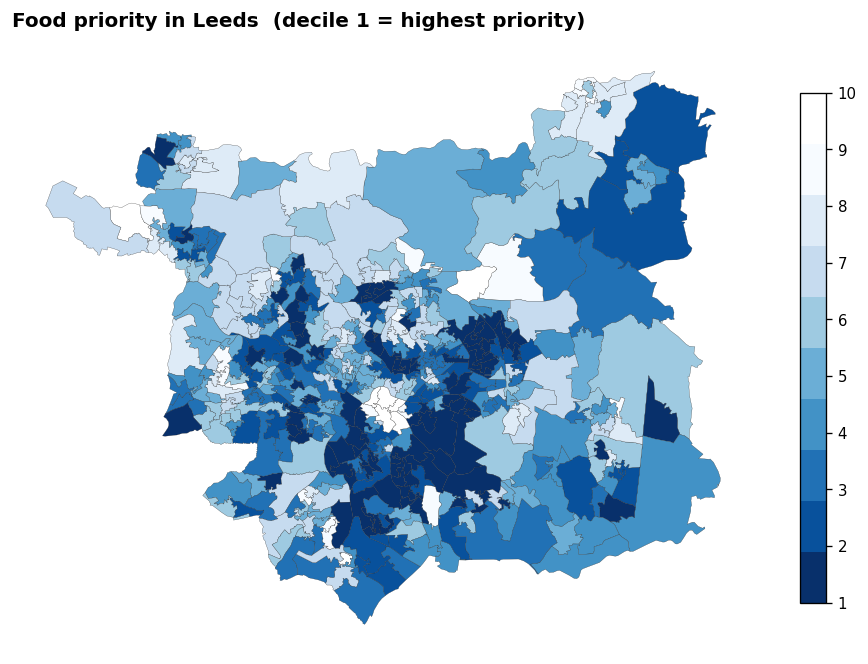

156 of 488 neighbourhoods are high food-priority (decile ≤ 2).


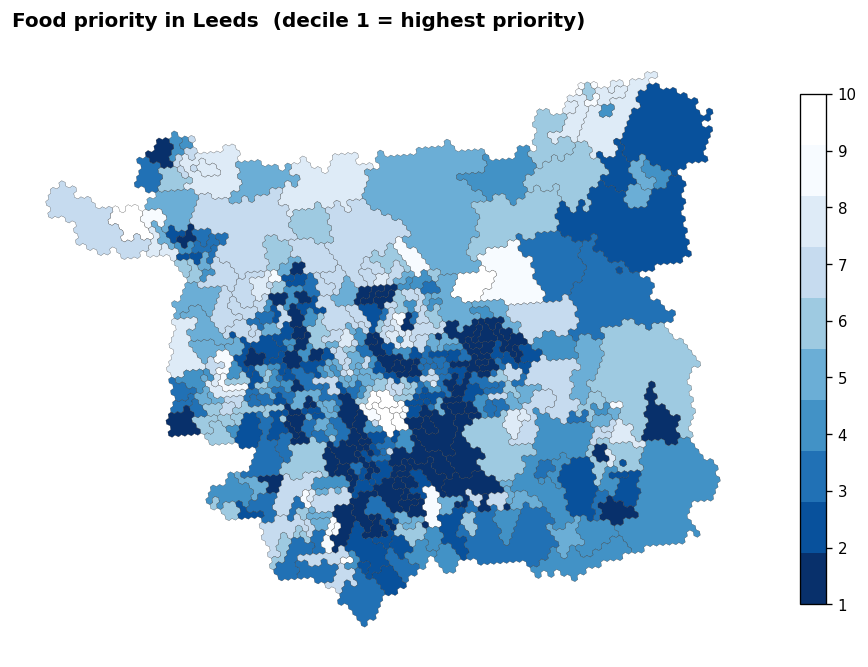

In [17]:
show_map(area, "food_decile", f"Food priority in {AREA_NAME}  (decile 1 = highest priority)")

n_high = high_need(area["food_decile"]).sum()
print(f"{n_high} of {len(area)} neighbourhoods are high food-priority (decile ≤ {WORST}).")

# try out mapping with H3 shapes by approximating lsoa shapes
show_map_h3(area, "food_decile", f"Food priority in {AREA_NAME}  (decile 1 = highest priority)", res=9)


---
# C. Do different problems hit the same places?

**What the next cell does:** measures how much food priority, deprivation and insulation need agree
(rank correlation), then checks how many high food-need areas are *also* high on the other two.

**Why:** if every index pointed at the same neighbourhoods, you'd only need one. Whether they overlap
is exactly what decides if "just use deprivation" is good enough.

**How to read it:** correlation runs from −1 to +1. Near **+1** = the two indices rank places almost
identically; near **0** = unrelated; **negative** = they point in *opposite* directions. The
percentages below say, of the worst food-need areas, what share are also worst on each other measure.
A low percentage is a finding, not a mistake - it means that problem lives somewhere else.

The **heatmap** counts neighbourhoods in each food × deprivation decile combination - a bright band along the diagonal means the two indices mostly agree; mass off the diagonal means they point at different places.

How much do the three indices agree?  (Spearman rank correlation, 1.0 = identical ordering)



,food_decile,imd_decile,insulation_decile
food_decile,1.00,0.74,0.16
imd_decile,0.74,1.00,0.22
insulation_decile,0.16,0.22,1.00



156 neighbourhoods are high food-need. Of those:
  66% are also high deprivation
  21% are also high insulation need


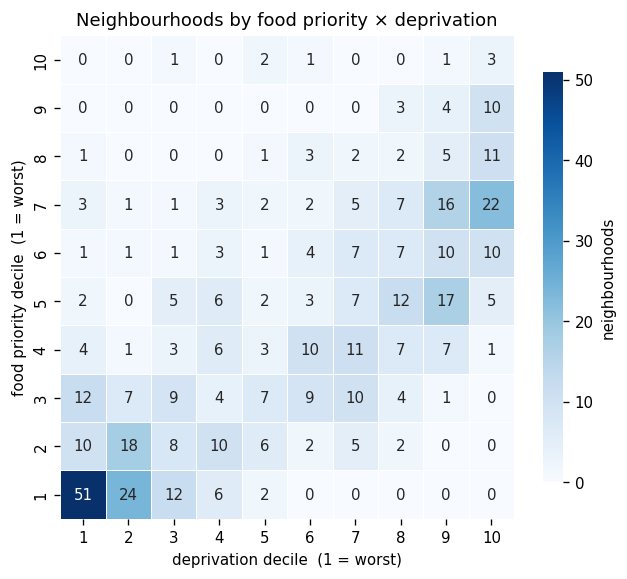

In [18]:

indices = ["food_decile", "imd_decile", "insulation_decile"]
print("How much do the three indices agree?  (Spearman rank correlation, 1.0 = identical ordering)\n")
display(area[indices].corr(method="spearman").round(2))

# of the worst-food neighbourhoods, how many are ALSO worst on the others?
worst_food = area[high_need(area["food_decile"])]
print(f"\n{len(worst_food)} neighbourhoods are high food-need. Of those:")
print(f"  {high_need(worst_food['imd_decile']).mean():.0%} are also high deprivation")
print(f"  {high_need(worst_food['insulation_decile']).mean():.0%} are also high insulation need")
# 10x10 heatmap: how many neighbourhoods fall in each food x deprivation decile combination
grid = (pd.crosstab(area["food_decile"], area["imd_decile"])
          .reindex(index=range(1, 11), columns=range(1, 11), fill_value=0))

fig, ax = plt.subplots(figsize=(5.4, 4.9))
sns.heatmap(
    grid,
    ax=ax,
    cmap="Blues",
    annot=True,
    fmt="d",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"shrink": 0.85, "label": "neighbourhoods"},
)

ax.hexbin(area["food_decile"], area["imd_decile"], gridsize=10, cmap="Blues", mincnt=1, edgecolors="white", linewidths=0.5)

ax.invert_yaxis()  # keep decile 1 at the bottom, matching the previous plot orientation
ax.set(
    xlabel="deprivation decile  (1 = worst)",
    ylabel="food priority decile  (1 = worst)",
    title="Neighbourhoods by food priority × deprivation",
)
plt.tight_layout()
plt.show()

The heatmap *counts*; a **map shows where**. Same two indices, on the ground: teal = food priority
only, pink = deprivation only, **dark = worst on both**, pale = fine on both. Where the two colours
split is where a food-specific index like PPFI earns its place.

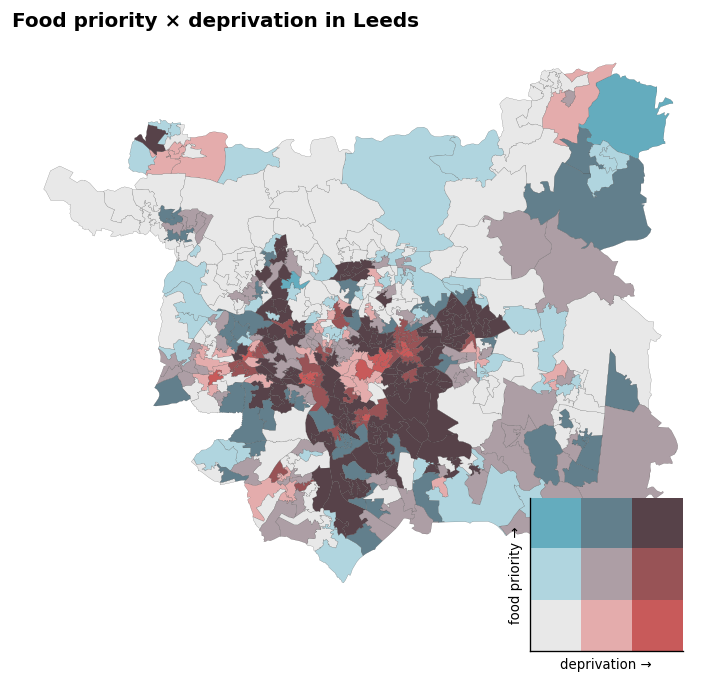

In [28]:
# Bivariate map: where do food priority and deprivation agree, and where do they diverge?
def tercile(s): return pd.qcut(s.rank(method="first"), 3, labels=[0, 1, 2]).astype(int)
f3 = tercile(11 - area["food_decile"])    # 2 = worst third for food priority
d3 = tercile(11 - area["imd_decile"])      # 2 = worst third for deprivation
area["biv"] = (f3 * 3 + d3).values

# 3x3 bivariate key: teal = food, pink = deprivation, dark = both worst
BIV = ["#e8e8e8", "#e4acac", "#c85a5a",
       "#b0d5df", "#ad9ea5", "#985356",
       "#64acbe", "#627f8c", "#574249"]

fig, ax = plt.subplots(figsize=(7.5, 7.5))
area.plot(color=[BIV[b] for b in area["biv"]], ax=ax, edgecolor="#333333", linewidth=0.1)
ax.set_title(f"Food priority × deprivation in {AREA_NAME}", fontsize=12, weight="bold", loc="left")
ax.set_axis_off()

key = fig.add_axes([0.70, 0.13, 0.17, 0.17])   # small 3x3 legend
key.imshow(np.arange(9).reshape(3, 3), cmap=ListedColormap(BIV), origin="lower")
key.set_xlabel("deprivation →", fontsize=8); key.set_ylabel("food priority →", fontsize=8)
key.set_xticks([]); key.set_yticks([])
plt.show()

<div style="background:#e8f4f8;padding:12px;border-left:4px solid #4a90a4">

### ✏️ Group task 1 - swap the comparison (5 min)

The heatmap and bivariate map compare food priority with deprivation. Change **one variable** to compare
food priority with **insulation need** instead (use `insulation_decile`), re-run the cell, and eyeball it:
does insulation need track food priority as tightly as deprivation did? What would a council miss if it
only ever looked at deprivation?
</div>

---
# D. Where do the burdens stack up?  ← the thing to take away

**What the next cell does:** for every neighbourhood, counts how many of the three problems - food
priority, deprivation, insulation need - it falls in the worst fifth for. That's a **0–3 "stacked burden"
score**. Then it maps the score and lists the worst ten.

**Why:** a place with one problem is different from a place with three at once. Stacking them finds
where a single intervention would relieve the most pressure.

**How to read it:** **3** = worst fifth on *all three* measures - the hardest-hit neighbourhoods,
shown darkest blue on the map. The **top-10 table** is the concrete output - real, named
neighbourhoods you could walk into a meeting with. (Change `WORST` in the config to see how sensitive
the short list is to where you draw the "high need" line.)

Leeds neighbourhoods by number of stacked burdens:


burden_count
0    245
1    114
2    106
3     23
Name: neighbourhoods, dtype: int64


Top 10 highest-need neighbourhoods in Leeds:


,name,district,food_decile,imd_decile,insulation_decile,burden_count
0,Leeds 086B,Leeds,1,1,1.0,3
1,Leeds 082A,Leeds,1,1,1.0,3
2,Leeds 082C,Leeds,1,1,1.0,3
3,Leeds 082D,Leeds,1,1,1.0,3
4,Leeds 086D,Leeds,1,1,1.0,3
5,Leeds 048B,Leeds,1,1,1.0,3
6,Leeds 048D,Leeds,1,1,1.0,3
7,Leeds 070D,Leeds,1,1,1.0,3
8,Leeds 075B,Leeds,1,1,1.0,3
9,Leeds 075C,Leeds,1,1,1.0,3


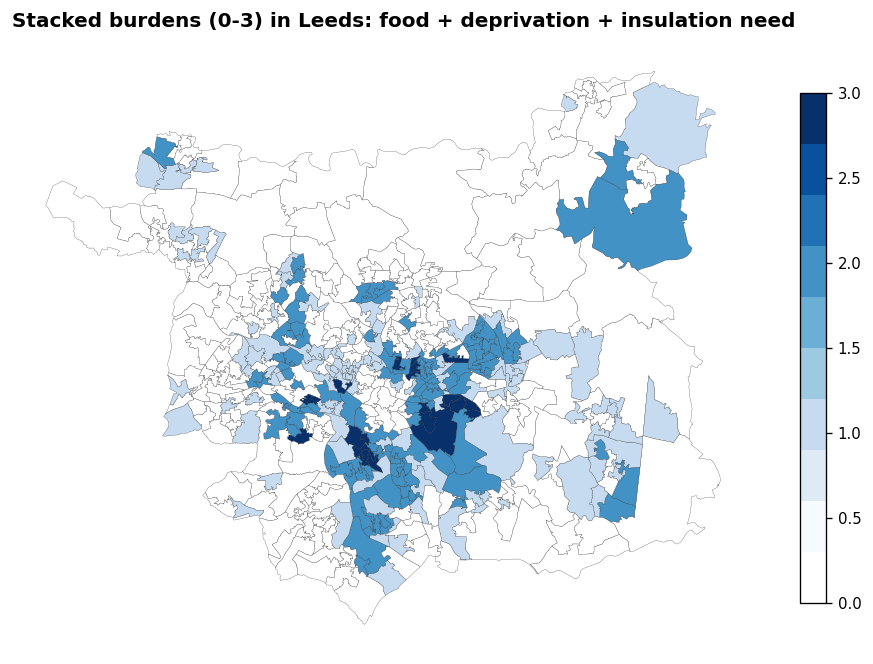

In [29]:
area["burden_count"] = (high_need(area["food_decile"]).astype(int)
                      + high_need(area["imd_decile"]).astype(int)
                      + high_need(area["insulation_decile"]).astype(int))

print(f"{AREA_NAME} neighbourhoods by number of stacked burdens:")
display(area["burden_count"].value_counts().sort_index().rename("neighbourhoods"))

# worst-off first: most burdens, then lowest average decile as a tie-break
area["mean_decile"] = area[["food_decile", "imd_decile", "insulation_decile"]].mean(axis=1)
top10 = area.sort_values(["burden_count", "mean_decile"], ascending=[False, True]).head(10)
print(f"\nTop 10 highest-need neighbourhoods in {AREA_NAME}:")
display(top10[["name", "district", "food_decile", "imd_decile", "insulation_decile",
               "burden_count"]].reset_index(drop=True))

# the takeaway map
show_map(area, "burden_count",
         f"Stacked burdens (0-3) in {AREA_NAME}: food + deprivation + insulation need", cmap=HASP_BLUES)

---
# E. Take it further - two ways, both hands-on

You've got a defensible short list. Two final ways to push it further: **make the map sing in
kepler.gl**, and **ask the data questions in plain English** with the HASP query tool. Run the export
cell first, then work through the group tasks below.

In [30]:
# GeoJSON of the polygons - drop straight into kepler.gl for a styled choropleth
area.to_file("area_need.geojson", driver="GeoJSON")
# flat table (no geometry) for spreadsheets or an LLM
area.drop(columns="geometry").to_csv("area_need.csv", index=False)
print("wrote area_need.geojson and area_need.csv")

try:
    from google.colab import files
    files.download("area_need.geojson")
except Exception:
    pass

wrote area_need.geojson and area_need.csv


<div style="background:#f0f0f0;padding:14px;border-left:4px solid #666">

### ✏️ Group task 2 - build a map that argues for something (kepler, 10 min)

Run the cell above, then open **kepler.gl/demo → Add Data** and drop in `area_need.geojson`
(it downloaded to your machine). Kepler builds the map on its own - now make it *say* something:

- **Colour** by `burden_count` (or `food_decile`) - Layer → Fill Colour
- **Colour scale → Quantize** - watch the story shift as you change the scale
- **3D**: turn on Height and extrude by `burden_count` - the hardest-hit areas rise as peaks
- **Filter** `food_decile` ≤ 2 - the map collapses to just where you'd act

Build **one** map you could put in front of a councillor, and be ready to say - in a single sentence -
what it argues for. Then **Share → Export Image** for your slide.
</div>

<div style="background:#f0f0f0;padding:14px;border-left:4px solid #666">

### ✏️ Group task 3 - ask the tool, then check it (15 min)

Open the live HASP query tool: **https://&lt;your-live-link&gt;**

**1. Reproduce something we did.** Ask it, in your own words, for a result you already have from this
notebook - for example:
- *"How many neighbourhoods in Leeds are in the worst fifth for food priority?"* (we got **156**)
- *"Which neighbourhoods are worst-fifth for food, deprivation **and** insulation need?"* (our
  triple-burden short list)

Does its number match ours? If not - whose is right, and why?

**2. Then go beyond the notebook.** Ask something we *didn't* - e.g. *"average deprivation decile by
district,"* or *"areas that are high food-need but not deprived."*

**Check every answer** the way you checked the notebook:
- did it get the **direction** right (decile 1 = worst, not 10)?
- is it using the **column you meant** (food vs deprivation vs insulation)?
- did it quietly **drop or include** the areas with missing data?

**Report back:** where did the tool nail it, and where did you have to catch it?

> **Facilitator note:** keep screenshots of 2–3 good queries + their results as a backup. If the live
> tool is slow or down, the session still runs off the screenshots.
</div>

In [31]:
# Optional scratch - cross-check a tool answer against the data yourself.
# e.g. count the "worst fifth for food priority" in this area:
#     high_need(area["food_decile"]).sum()
# `area` is ready to use. Remember: decile 1 = worst (highest need).

<div style="background:#f0f0f0;padding:14px;border-left:4px solid #666">

### ✏️ Group task 4 (optional / take-home) - *why* is it worst? PPFI's seven domains (10 min)

We've treated food priority as one number. But PPFI is built from **seven domains**, and two
neighbourhoods with the *same* headline decile can be worst for completely different reasons. The
cell below profiles one neighbourhood across all seven.

- Change `pick` to a name from your top-10 table and re-run. Try a couple.
- Notice which domains drive it. In a city like Leeds it's rarely *distance to a supermarket* - it's
  usually **socio-economic**, **fuel poverty**, and **online / delivery access**.
- That last one, `d_online_access`, is a **digital-divide-in-food** story: neighbourhoods cut off from
  online grocery shopping. What would you do differently for a "can't get online" area vs a
  "can't afford it" one?
</div>

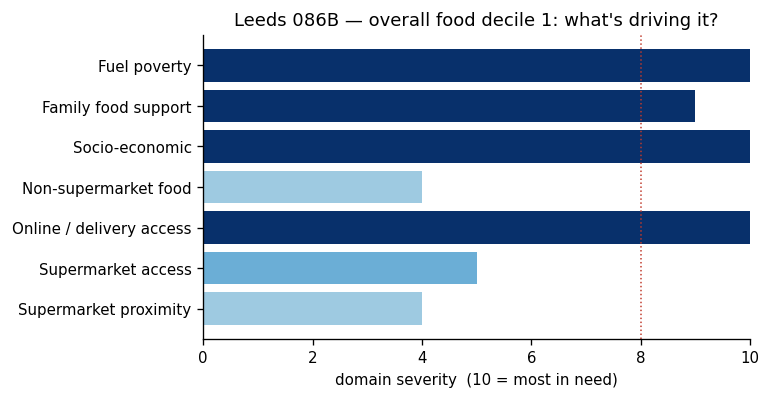

In [32]:
DOMAIN_LABELS = {
    "d_supermarket_proximity": "Supermarket proximity",
    "d_supermarket_access":    "Supermarket access",
    "d_online_access":         "Online / delivery access",
    "d_nonsupermarket":        "Non-supermarket food",
    "d_socioeconomic":         "Socio-economic",
    "d_family_support":        "Family food support",
    "d_fuel_poverty":          "Fuel poverty",
}

pick = "Leeds 086B"      # <- change to any 'name' from the top-10 table, then re-run
row  = area.loc[area["name"] == pick].iloc[0]
sev  = [11 - row[c] for c in DOMAIN_LABELS]        # severity: 10 = worst on that domain

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.barh(list(DOMAIN_LABELS.values()), sev, color=[HASP_BLUES(s / 10) for s in sev])
ax.set(xlim=(0, 10), xlabel="domain severity  (10 = most in need)",
       title=f"{pick} - overall food decile {int(row['food_decile'])}: what's driving it?")
ax.axvline(8, color="#c0392b", ls=":", lw=0.9)    # a domain is a real driver past here
plt.tight_layout(); plt.show()

---
## Where this goes next

In an afternoon you did what HASP does across every neighbourhood in the UK: pulled several open,
LSOA-level datasets together and turned them into a short, defensible list of places to act.

**Honest limits** - they decide whether you can trust any of it:
- "worst fifth" (decile ≤ 2) is a choice; move `WORST` and the short list moves with it
- three equally-weighted burdens is a simplification - a real brief would weight and justify them
- indices can even disagree on *direction* (we flipped insulation) - always check before combining
- none of these numbers carry uncertainty, and a real analysis must

**Datasets:** PPFI v2.1 (HASP) · IMD 2025 · Which? Insulation Index.
**Cite PPFI:** Pontin, F., Oldroyd, R., Baudains, P., Ennis, E., Newing, A. & Morris, M. (2024).
*Priority Places for Food Index* (v2.1). HASP (ES/Z504336/1). doi:10.82147/003

**Talk to us - hasp.ac.uk**

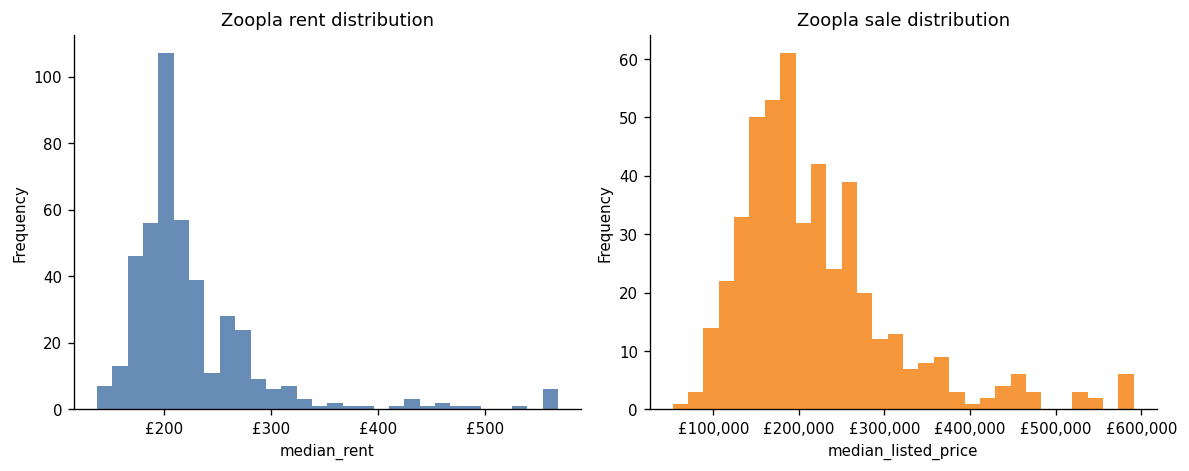

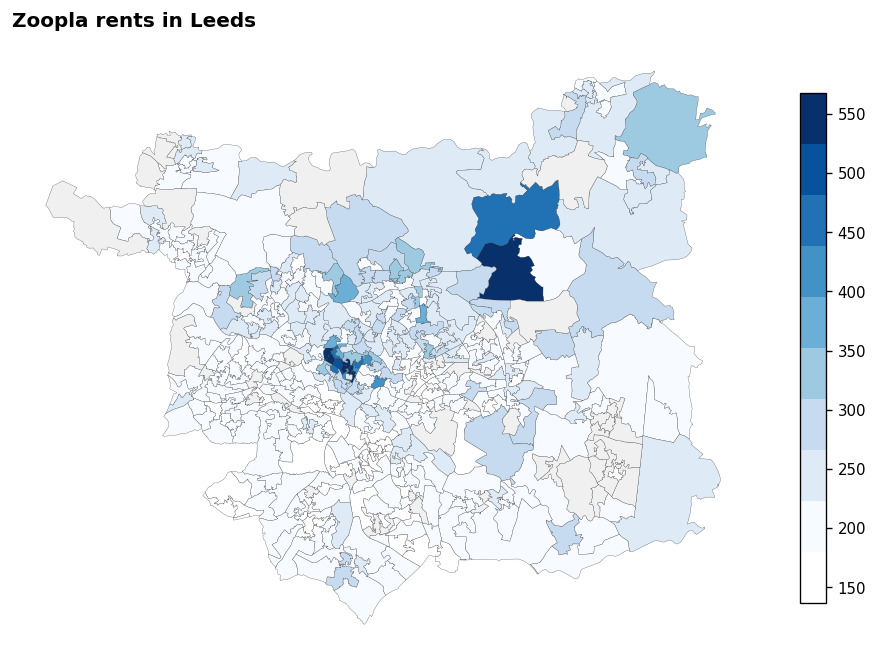

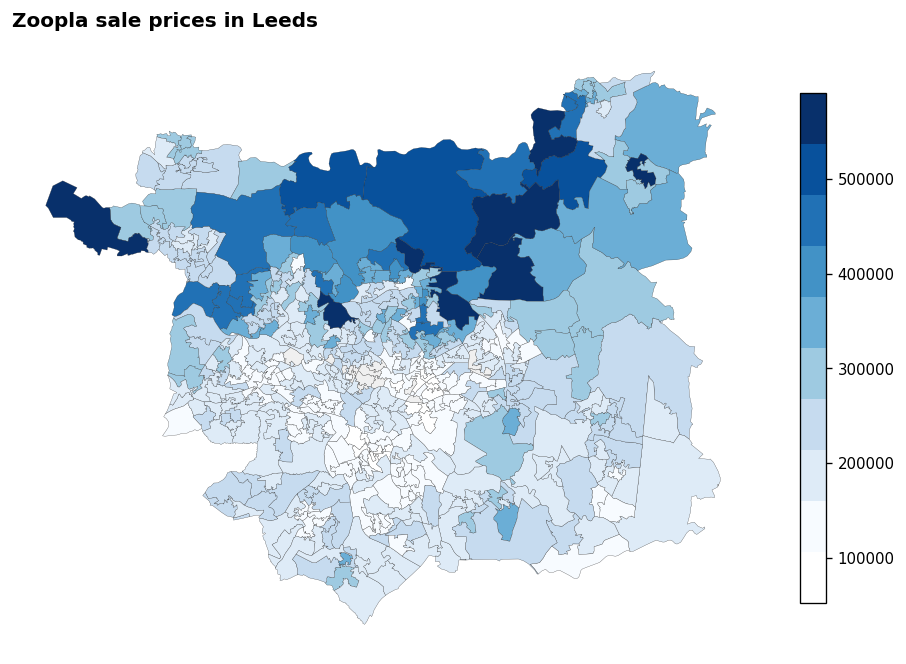

In [41]:
rent_df = pd.read_csv('./data/zoopla_rent.csv')
sale_df = pd.read_csv('./data/zoopla_sale.csv')

rent_lsoa = 'lsoa_code'
sale_lsoa = 'lsoa_code'
rent_val = 'median_rent'
sale_val = 'median_listed_price'

# only keep the LSOAs that are in our area of interest
rent_df = rent_df[rent_df[rent_lsoa].isin(area['lsoa'])]
sale_df = sale_df[sale_df[sale_lsoa].isin(area['lsoa'])]
rent_df = rent_df[rent_df['closing_year'] == 2024]
sale_df = sale_df[sale_df['closing_year'] == 2024]

# keep only 99th percentile to avoid a long tail
sale_max = sale_df[sale_val].quantile(0.99)
sale_df[sale_val] = sale_df[sale_val].clip(upper=sale_max)
rent_max = rent_df[rent_val].quantile(0.99)
rent_df[rent_val] = rent_df[rent_val].clip(upper=rent_max)

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
rent_df[rent_val].dropna().plot(kind="hist", bins=30, ax=axes[0], color="#4C78A8", alpha=0.85)
axes[0].set_title("Zoopla rent distribution")
axes[0].set_xlabel(rent_val)

sale_df[sale_val].dropna().plot(kind="hist", bins=30, ax=axes[1], color="#F58518", alpha=0.85)
axes[1].set_title("Zoopla sale distribution")
axes[1].set_xlabel(sale_val)
# make the xticks formatted as currency without scientific notation, but with commas for thousands
axes[0].xaxis.set_major_formatter('£{x:,.0f}')
axes[1].xaxis.set_major_formatter('£{x:,.0f}')

plt.tight_layout()
plt.show()

if rent_lsoa and sale_lsoa:
    r = rent_df[[rent_lsoa, rent_val]].rename(columns={rent_lsoa: "lsoa", rent_val: "zoopla_rent"})
    s = sale_df[[sale_lsoa, sale_val]].rename(columns={sale_lsoa: "lsoa", sale_val: "zoopla_sale"})
    zoopla = r.merge(s, on="lsoa", how="outer")

    area_zoopla = area.merge(zoopla, on="lsoa", how="left")

    # Rent map
    show_map(
        area_zoopla,
        "zoopla_rent",
        f"Zoopla rents in {AREA_NAME}",
        cmap=HASP_BLUES
    )

    # Sale map
    show_map(
        area_zoopla,
        "zoopla_sale",
        f"Zoopla sale prices in {AREA_NAME}",
        cmap=HASP_BLUES
    )
else:
    print("Skipping maps: could not detect LSOA key in both rent and sale files.")

In [42]:
# export these geojsons after slightly simpliygin geometry
area_zoopla = area_zoopla.copy()
area_zoopla["geometry"] = area_zoopla["geometry"].simplify(tolerance=0.001, preserve_topology=True)
area_zoopla.to_file("area_zoopla.geojson", driver="GeoJSON")